In [2]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd 
import numpy as np
import glob
import os

In [2]:
PATH_TO_DATA = "../data/valid_comb_data.csv"

data = pd.read_csv(PATH_TO_DATA)

def label_bliss(bliss_score):
    if bliss_score <= -0.3:
        return "antagonistic"
    elif bliss_score >= 0.3:
        return "synergistic"
    else:
        return "additive"

data['bliss_label'] = data['bliss_med'].apply(label_bliss)

data.drop("cp_SMILES", axis=1, inplace=True)

strains_info = {"Ab17978":{'Specie':"A. baumannii", "Phenotype":"S"},
                "AbLac4":{'Specie':"A. baumannii", "Phenotype":"R"},
                "Kp43816":{'Specie':"K. pneumoniae", "Phenotype":"S"},
                "Kp0087":{'Specie':"K. pneumoniae", "Phenotype":"R"},
                "PAO1":{'Specie':"P. aeruginosa", "Phenotype":"S"},
                "Pa0095":{'Specie':"P. aeruginosa", "Phenotype":"R"},
}
data['Specie'] = data['strain_name'].apply(lambda x: strains_info[x]['Specie'])
data['Phenotype'] = data['strain_name'].apply(lambda x: strains_info[x]['Phenotype'])

In [3]:
print(f"Number of combinations in the dataset: {len(data)}")

Number of combinations in the dataset: 773611


In [4]:
# Count data per label
print("\nCount of data per bliss_label:")
label_counts = data['bliss_label'].value_counts()
print(label_counts)
print("\nPercentage of data per bliss_label:")
print(label_counts/(len(data)) * 100)


Count of data per bliss_label:
bliss_label
additive        739680
antagonistic     30277
synergistic       3654
Name: count, dtype: int64

Percentage of data per bliss_label:
bliss_label
additive        95.613946
antagonistic     3.913724
synergistic      0.472330
Name: count, dtype: float64


In [5]:
# Count of unique abx_name
unique_abx_count = data['abx_name'].nunique()
print(f"Count of unique abx_name: {unique_abx_count}")
unique_cp_count = data['cp_name'].nunique()
print(f"Count of unique cp_name: {unique_cp_count}")

Count of unique abx_name: 27
Count of unique cp_name: 27700


In [6]:
# Data count by strain_name
print("Data count by strain_name:")
data.groupby('strain_name').size()

Data count by strain_name:


strain_name
Ab17978    156818
AbLac4     118614
Kp0087     107881
Kp43816    168814
PAO1       106642
Pa0095     114842
dtype: int64

In [7]:
# Data count by strain name and bliss_label
data_count_by_strain_bliss = data.groupby(['strain_name', 'bliss_label']).size().unstack(fill_value=0)
print("\nData count by strain_name and bliss_label:")
print(data_count_by_strain_bliss)


Data count by strain_name and bliss_label:
bliss_label  additive  antagonistic  synergistic
strain_name                                     
Ab17978        146389          9456          973
AbLac4         113003          5155          456
Kp0087         103875          3422          584
Kp43816        160812          6972         1030
PAO1           104175          2116          351
Pa0095         111426          3156          260


In [8]:
# Data count by unique abx_name
print("\nCount of unique abx_name screened by strain:")
data.groupby('strain_name')['abx_name'].nunique()


Count of unique abx_name screened by strain:


strain_name
Ab17978    25
AbLac4     23
Kp0087     25
Kp43816    27
PAO1       23
Pa0095     23
Name: abx_name, dtype: int64

In [9]:
# Data count by unique cp_name
print("\nCount of unique cp_name screened by strain:")
data.groupby('strain_name')['cp_name'].nunique()


Count of unique cp_name screened by strain:


strain_name
Ab17978    22017
AbLac4      7752
Kp0087      7936
Kp43816    26828
PAO1        7438
Pa0095      7397
Name: cp_name, dtype: int64

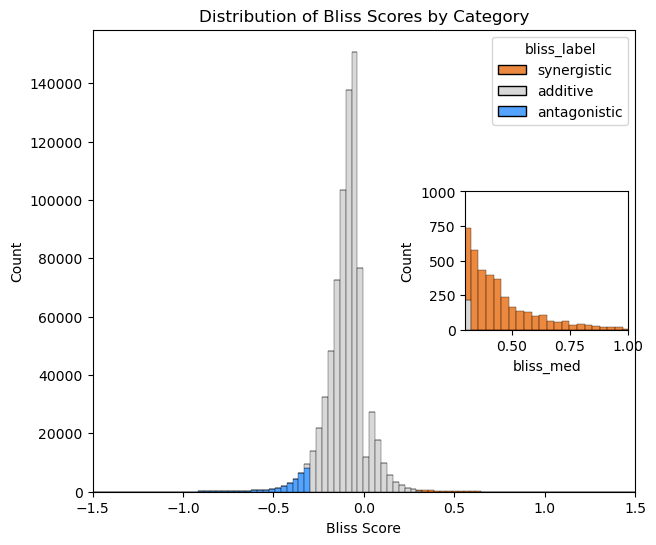

In [10]:
# Colors for categories
color_map = {'antagonistic': '#1A85FF', 
            'additive': '#CCCCCC',
            'synergistic': '#E66100'}

# Histplot, hue by bliss_label
fig, ax = plt.subplots(figsize=(7, 6))
sns.histplot(data=data, x='bliss_med', hue='bliss_label', palette=color_map, multiple='stack', bins=150, ax=ax)
ax.set_title('Distribution of Bliss Scores by Category')
ax.set_xlabel('Bliss Score')
ax.set_ylabel('Count')
ax.set_xlim(-1.5, 1.5)

ax_inset = inset_axes(ax, width="30%", height="30%", loc='center right')
sns.histplot(data=data, x='bliss_med', 
             hue='bliss_label', 
             palette=color_map, 
             multiple='stack', 
             bins=150, 
             ax=ax_inset,
             legend=False)

ax_inset.set_xlim(0.3, 1.0)
ax_inset.set_ylim(0, 1000)
plt.show()

In [11]:
# Count unique combinations 
unique_combinations = data.groupby(['abx_name', 'cp_name']).size().reset_index(name='count')

print("\nPossible unique combinations of abx_name and cp_name:")
print(unique_abx_count * unique_cp_count)

print("\nCount of unique combinations of abx_name and cp_name present in the dataset:")
print(len(unique_combinations))

print("\nPercentage of unique combinations present in the dataset from possible combinations:")
print((len(unique_combinations) / (unique_abx_count * unique_cp_count)) * 100)


Possible unique combinations of abx_name and cp_name:
747900

Count of unique combinations of abx_name and cp_name present in the dataset:
255666

Percentage of unique combinations present in the dataset from possible combinations:
34.184516646610504


In [12]:
n_strains = data['strain_name'].nunique()

# Count of combinations present in all strains
combinations_in_all_strains = unique_combinations[unique_combinations['count'] == n_strains]

print("\nCount of unique combinations of abx_name and cp_name present in all strains:")
print(len(combinations_in_all_strains))


Count of unique combinations of abx_name and cp_name present in all strains:
12945


In [13]:
synergistic_data = data[data['bliss_label'] == 'synergistic']
antagonistic_data = data[data['bliss_label'] == 'antagonistic']

# Any combination synergistic in the six strains?
synergistic_combinations = synergistic_data.groupby(['abx_name', 'cp_name']).size().reset_index(name='count')
synergistic_in_all_strains = synergistic_combinations[synergistic_combinations['count'] == n_strains]
if len(synergistic_in_all_strains) > 0:
    print("\nYes, there are synergistic combinations present in all strains.")
else:
    print("\nNo, there are no synergistic combinations present in all strains.")

antagonistic_combinations = antagonistic_data.groupby(['abx_name', 'cp_name']).size().reset_index(name='count')
antagonistic_in_all_strains = antagonistic_combinations[antagonistic_combinations['count'] == n_strains]
if len(antagonistic_in_all_strains) > 0:
    print("\nYes, there are antagonistic combinations present in all strains.")
    print(f"\nCount of unique antagonistic combinations present in all strains: {len(antagonistic_in_all_strains)}")
else:
    print("\nNo, there are no antagonistic combinations present in all strains.")


No, there are no synergistic combinations present in all strains.

Yes, there are antagonistic combinations present in all strains.

Count of unique antagonistic combinations present in all strains: 23


In [14]:
n_phenotypes = data['Phenotype'].nunique()

# Are there combiations synergistics in both phenotypes per Species?
synergistic_per_species_phenotype = synergistic_data.groupby(['Specie', 'abx_name', 'cp_name']).size().reset_index(name='count')

synergistic_combinations_both_phenotypes = synergistic_per_species_phenotype[synergistic_per_species_phenotype['count'] == n_phenotypes]

print(f"\nCount of unique synergistic combinations of abx_name and cp_name present in both phenotypes per Species: {len(synergistic_combinations_both_phenotypes)}")
synergistic_combinations_both_phenotypes.groupby('Specie').size().reset_index(name='count')



Count of unique synergistic combinations of abx_name and cp_name present in both phenotypes per Species: 36


,Specie,count
0,A. baumannii,14
1,K. pneumoniae,13
2,P. aeruginosa,9


In [15]:
# Are there combiations antagonistic in both phenotypes per Species?
antagonistic_per_species_phenotype = antagonistic_data.groupby(['Specie', 'abx_name', 'cp_name']).size().reset_index(name='count')

antagonistic_combinations_both_phenotypes = antagonistic_per_species_phenotype[antagonistic_per_species_phenotype['count'] == n_phenotypes]

print(f"\nCount of unique antagonistic combinations of abx_name and cp_name present in both phenotypes per Species: {len(antagonistic_combinations_both_phenotypes)}")
antagonistic_combinations_both_phenotypes.groupby('Specie').size().reset_index(name='count')


Count of unique antagonistic combinations of abx_name and cp_name present in both phenotypes per Species: 782


,Specie,count
0,A. baumannii,184
1,K. pneumoniae,206
2,P. aeruginosa,392


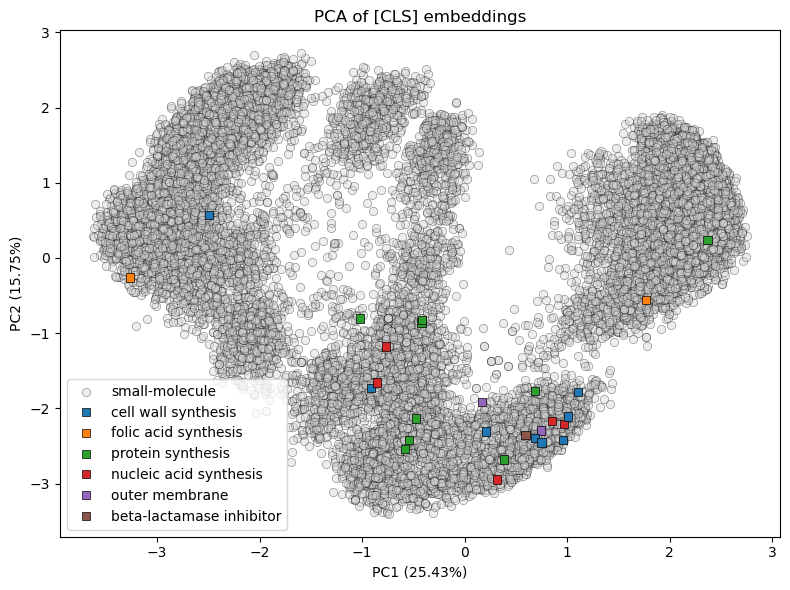

In [5]:
# chemical space visualization

def build_map_indexes(norm_abx, norm_small_mols):

    # Create mapping from antibiotic and small molecule names to their respective embedding indices
    abx_to_index = pd.Series(norm_abx.index, index=norm_abx['abx_name']).to_dict()
    small_mol_to_index = pd.Series(norm_small_mols.index, index=norm_small_mols['cp_name']).to_dict()
    return abx_to_index, small_mol_to_index


# PCA of embeddings
abx_embs = np.load('../data/abx_embs.npz')
sm_embs = np.load('../data/small_mol_embs.npz')

abx_norm = pd.read_csv('../data/normalized_abx.csv')
sm_norm = pd.read_csv('../data/normalized_small_mol.csv')

abx_to_index, sm_to_index = build_map_indexes(abx_norm, sm_norm)


abx_metadata = pd.read_csv('../metadata/antibiotics_names.txt')

# Obtain type list of antibiotics from abx_to_index and abx_metadata
abx_types = abx_metadata.set_index('abx_name').loc[abx_to_index.keys()]['process_target'].to_dict()

abx_indices = [abx_to_index[abx] for abx in abx_types.keys()]
abx_embs = abx_embs['embeddings'][abx_indices]

stacked_embs = np.vstack((abx_embs, sm_embs['embeddings']))

pca_embs = PCA().fit(stacked_embs)

# calculate the explained variance ratio
explained_variance_ratio = pca_embs.explained_variance_ratio_
pca1_var = explained_variance_ratio[0] * 100
pca2_var = explained_variance_ratio[1] * 100

fig, axes = plt.subplots( figsize=(8, 6))

sns.scatterplot(x=pca_embs.transform(sm_embs['embeddings'])[:, 0], 
             y=pca_embs.transform(sm_embs['embeddings'])[:, 1], 
             marker='o', color='lightgray', edgecolor="black", linewidth=0.5, 
             label='small-molecule', alpha=0.4, ax=axes)
sns.scatterplot(x=pca_embs.transform(abx_embs)[:, 0],
             y=pca_embs.transform(abx_embs)[:, 1],
             marker='s', color='#1b9e77', hue = abx_types.values(),
             edgecolor="black", linewidth=0.5, 
             alpha=1, ax=axes)
# axes.scatter(pca_embs.transform(sm_embs['embeddings'])[:, 0], 
#              pca_embs.transform(sm_embs['embeddings'])[:, 1], 
#              marker='o',color='lightgray', edgecolors="black", linewidth=0.5, 
#                 label='small-molecule', alpha=0.4 )
# axes.scatter(pca_embs.transform(abx_embs)[:, 0],
#              pca_embs.transform(abx_embs)[:, 1],
#              marker='s', color='#1b9e77', hue=abx_types.values(), edgecolors="black", linewidth=0.5, 
#                 label='antibiotic', alpha=1)
axes.legend()

axes.set_title('PCA of [CLS] embeddings')
axes.set_xlabel(f'PC1 ({pca1_var:.2f}%)')
axes.set_ylabel(f'PC2 ({pca2_var:.2f}%)')

plt.tight_layout()
# # save the figure
plt.savefig('../data/plots/pca_embeddings.svg', dpi=300, bbox_inches='tight')
plt.savefig('../data/plots/pca_embeddings.png', dpi=300, bbox_inches='tight')

             